# Optimisation of problem using 3 algorithms

#### Imports


In [56]:
import numpy as np
import matplotlib.pyplot as plt
from math import sin

#### Define problem (McCormick function)


In [57]:
problem = lambda x, y: sin(x+y) + (x-y)**2 - 1.5*x + 2.5*y + 1

#### Generate 500 random solutions and plot fitness
First, we will generate 500 random solutions uniformly in the range -5 to 5 as suggested as a starting point. Then I calculate the fitness for each of the 500 solutions and plot the solutions vs the fitness on a scatter graph

In [58]:
# Generate 500 random solutions in the range [-5, 5]
x = np.random.uniform(-5, 5, 500)
y = np.random.uniform(-5, 5, 500)
fitness = np.array([problem(x, y) for x, y in zip(x, y)])

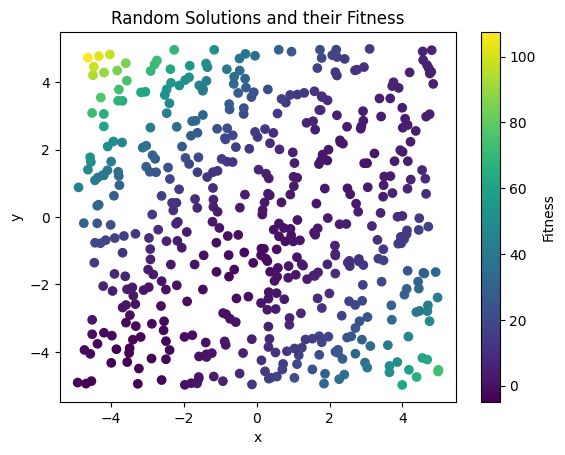

In [59]:
plt.scatter(x, y, c=fitness, cmap='viridis')
plt.colorbar(label='Fitness')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Random Solutions and their Fitness')
plt.show()

#### Define hillclimber algorithm using guassian mutation
The hillclimber function accepts an initial starting point, number of iterations, the problem and the mutation function.

I am using guassian mutation as a lambda which works by performing a random mutation from a normal distribution centered around 0 to the input.

The function starts by setting initial points as the best_x and best_y and evaluating initial fitness. Then for each iteration it applies a random mutation to x and y, recalculates the fitness, stores the solution and if the fitness is higher, it sets best_x, best_y and current fitness to the new solution.

After all iterations have completed, the best solution and all solutions are returned

In [60]:
gmutate = lambda x: x + np.random.normal(0, 0.1)
def hillclimb(x: float, y: float, fitness_func: callable, iterations: int) -> tuple:
    best_x, best_y = x, y
    current_fitness = fitness_func(best_x, best_y)
    solutions = np.array([[], [], []]).T
    for _ in range(iterations):
        new_x = gmutate(best_x)
        new_y = gmutate(best_y)
        new_fitness = fitness_func(new_x, new_y)
        solutions = np.append(solutions, [[new_x, new_y, new_fitness]], axis=0)

        if new_fitness < current_fitness:  # Assuming we want to minimize the fitness
            best_x, best_y, current_fitness = new_x, new_y, new_fitness

    return best_x, best_y, current_fitness, solutions

#### Run hillclimber and plot fitness per solution and over time
To run hillclimber I select a random start x and y from a uniform distribution between -5 and 5. Hillclimber is then ran with 200 iterations to find the best solution. 

This shows that the best solution is `x=-0.5423208525126813, y=-1.5487144195433582, fitness=-1.9131771860791327`, and that the fitness is stable after approximately 120 iterations. 

This solution (-0.5423, -1.548, fitness -1.913) is very close to the global minimum for the function (-0.54719, -1.54719, fitness -1.9133) when evaluated on the standard search space (x -1.5 to 4, y -3 to 4), however, on the expanded search space we are using here (-5, 5), it is not the global minimum. 

This shows that the hillclimber is getting stuck in a local optima.

Testing larger number of iterations (up to 20,000) shows that the algorithm does not recover from being stuck in the local optima (likely due to the low mutation making it unable to climb from a local optima found from the initial x and y).

However, running the hillclimb repeatedly, discovers many local optimas and shows the algorithm rarely fines the global minimum for the search space.

In [160]:
# Run hill climbing with a random initial solution
init_x, init_y = np.random.uniform(-5, 5, 2)
best_x, best_y, best_fitness, solutions = hillclimb(init_x, init_y, problem, 200)
print(f"Best solution: x={best_x}, y={best_y}, fitness={best_fitness}")

Best solution: x=2.5901389132150068, y=1.5812112133333662, fitness=1.2285806606137655


In [161]:
# Run hill climbing multiple times to see the distribution of fitnesses
fitnesses = []
for i in range(100):
    init_x, init_y = np.random.uniform(-5, 5, 2)
    best_x, best_y, best_fitness, solutions = hillclimb(init_x, init_y, problem, 200)
    fitnesses.append((i, best_fitness))

unique_fitnesses, counts = np.unique([np.round(f[1],2) for f in fitnesses], return_counts=True)

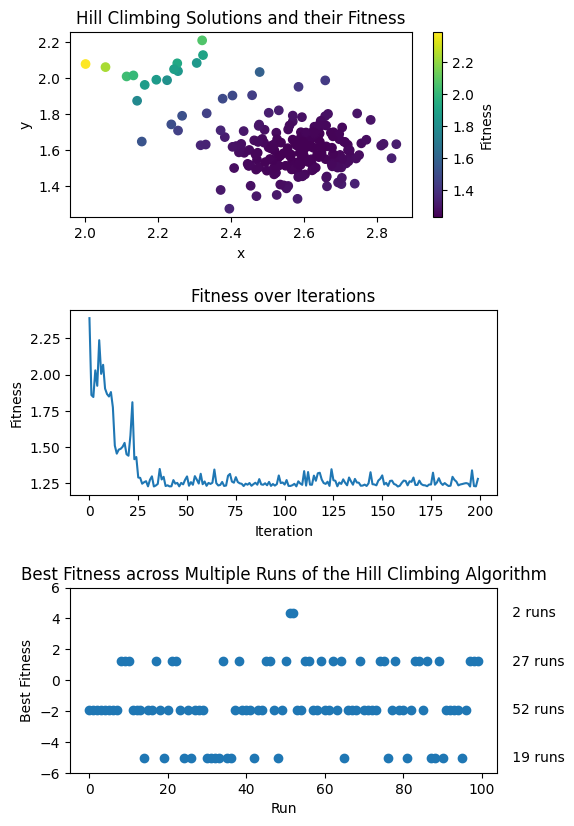

In [162]:
# Visualize the solutions and their fitnesses
fig, axs = plt.subplots(3)
fig.set_size_inches(5,8)
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
axs[0].scatter(solutions[:, 0], solutions[:, 1], c=solutions[:, 2], cmap="viridis")
fig.colorbar(axs[0].collections[0], label="Fitness")
axs[0].set_xlabel("x")
axs[0].set_ylabel("y")
axs[0].set_title("Hill Climbing Solutions and their Fitness")

axs[1].plot(solutions[:, 2])
axs[1].set_xlabel("Iteration")
axs[1].set_ylabel("Fitness")
axs[1].set_title("Fitness over Iterations")

axs[2].set_xlabel("Run")
axs[2].set_ylabel("Best Fitness")
axs[2].set_title("Best Fitness across Multiple Runs of the Hill Climbing Algorithm")
axs[2].scatter([x[0] for x in fitnesses], [x[1] for x in fitnesses])
for f, count in zip(unique_fitnesses, counts):
    axs[2].text(101, f, f"      {count} runs", va="center")
axs[2].set_ylim(-6, 6)
plt.show()

#### Define evolutionary algorithm
First I define mutate_and_eval, a helper function which will mutate the input values and evaluate the new values returning new_x, new_y, and new_fitness.

The evolutionary algorithm works by generating a population of `pop_size` with solutions uniformally distributed between -5 and 5, then fitness is calculated for each member. For each generation, each member is mutated, evaluated and added to the population. Then the population is pruned removing the bottom `pop_size` elements, and the best fitness per generation is stored.

Finally, the best solution overall is recorded and all results are returned.


In [63]:
def mutate_and_eval(x: float, y: float, fitness_func: callable) -> tuple:
    # Mutate x and y, then evaluate fitness
    new_x = gmutate(x)
    new_y = gmutate(y)
    new_fitness = fitness_func(new_x, new_y)
    return new_x, new_y, new_fitness

In [64]:
def evolutionary_algorithm(pop_size: int, generations: int, fitness_func: callable) -> tuple:
    pop = np.random.uniform(-5, 5, (pop_size, 2))
    fitness = np.array([fitness_func(x, y) for x, y in pop]).reshape(-1, 1)
    population = np.hstack((pop, fitness))
    best_fitness_per_gen = np.array([np.min(population[:, 2])]) 
    for _ in range(generations):
        children = np.array([mutate_and_eval(x, y, fitness_func) for x, y, _ in population]) # mutate each parent to create child and evaluate fitness
        population = np.vstack((population, children)) # combine parents and children
        population = population[np.argsort(population[:, 2])][:pop_size] # select top pop_size elements
        best_fitness_per_gen = np.append(best_fitness_per_gen, population[0, 2]) 
    best_solution = population[0]
    return best_solution[0], best_solution[1], best_solution[2], population, best_fitness_per_gen

#### Run evolutionary algorithm using 20 generations of 70 children
Running the evolutionary algorithm with 20 generations of 70 children finds the global minimum for our large search space (-5 to 5), which the hillclimber did not. This is due to the evolutionary algorithm having a large population spread which makes it much more resilient to local optimas. 

The choice of 20 generations with a population size of 70 was found by plotting fitness over generations for a set population size and reducing generations closer to the stagnant point. The algorithm was then run 100 times with the same parameters to plot the stability. 

Using a smaller population and number of generations still finds the correct answer, however, when ran 100 times it is possible to see that it gets caught in a local optima in a large percentage of runs. 

By tuning both the generation count and population size, I found that 20 generations of 70 children was a good choice as it only got stuck in a local optima in 1/100 runs. It would be possible to increase generations and population size to reduce this even further, however, this would increase execution time so it is a trade off between performance and accuracy / stability

In [65]:
best_x, best_y, best_fitness, solutions, best_fitness_per_gen = evolutionary_algorithm(70, 20, problem)
print(f"Best solution: x={best_x}, y={best_y}, fitness={best_fitness}")

Best solution: x=-3.702406103862934, y=-4.701165298298591, fitness=-5.0545230347296055


Text(0.5, 1.0, 'Best Fitness over Generations')

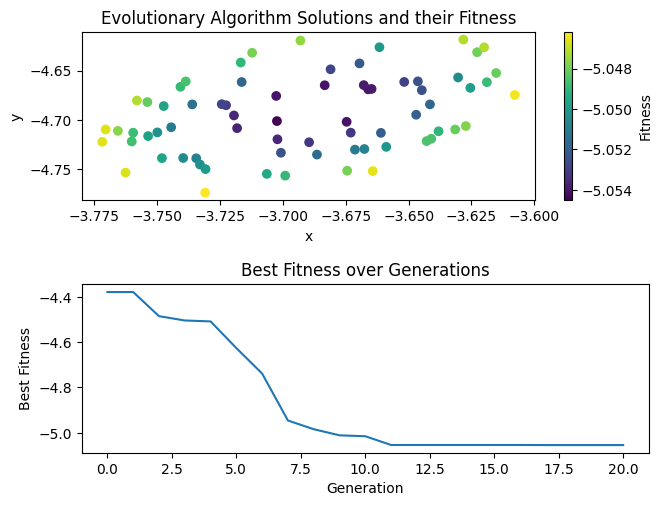

In [66]:
fig, axs = plt.subplots(2)
plt.tight_layout()
plt.subplots_adjust(hspace=0.5)
axs[0].scatter(solutions[:, 0], solutions[:, 1], c=solutions[:, 2], cmap='viridis')
fig.colorbar(axs[0].collections[0], label='Fitness')
axs[0].set_xlabel('x')
axs[0].set_ylabel('y')
axs[0].set_title('Evolutionary Algorithm Solutions and their Fitness')
axs[1].plot(best_fitness_per_gen)
axs[1].set_xlabel('Generation')
axs[1].set_ylabel('Best Fitness')
axs[1].set_title('Best Fitness over Generations')

#### Run evolutionary algorithm 100 times to evaluate stability

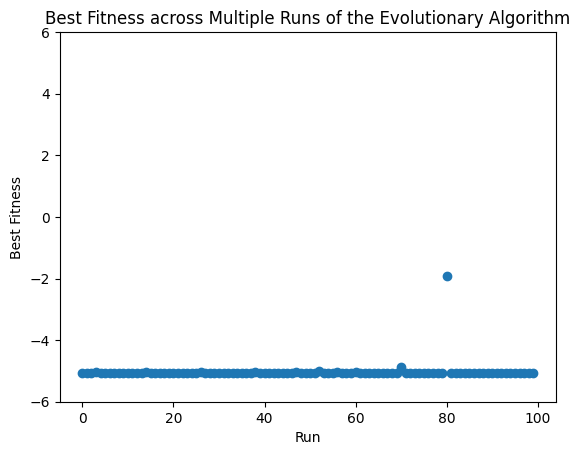

In [90]:
fitnesses = []
for i in range(100):
    best_x, best_y, best_fitness, solutions, best_fitness_per_gen = evolutionary_algorithm(70, 20, problem)
    fitnesses.append((i, best_fitness))
plt.scatter([x[0] for x in fitnesses], [x[1] for x in fitnesses])
plt.ylim(-6, 6)
plt.xlabel('Run')
plt.ylabel('Best Fitness')
plt.title('Best Fitness across Multiple Runs of the Evolutionary Algorithm')
plt.show()